<a href="https://colab.research.google.com/github/NadirLumin/Spoon-Knife/blob/main/Student_MLE_MiniProject_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project: Exploratory Data Analysis

# Exploratory Data Analysis: Unveiling Insights from the NYC Taxi Dataset

Data has become the lifeblood of the modern world, permeating every aspect of our lives and transforming the way we make decisions. In this era of vast information, the ability to extract meaningful insights from raw data has emerged as a crucial skill. Enter exploratory data analysis (EDA), a powerful approach that allows us to unravel hidden patterns, detect anomalies, and generate valuable knowledge from the vast volumes of data at our disposal.

Exploratory data analysis serves as the initial step in any data-driven investigation, offering a comprehensive understanding of the dataset's structure, distributions, and relationships between variables. By applying statistical and visual techniques, analysts gain a deeper insight into the data, paving the way for more accurate predictions, informed decision-making, and the discovery of actionable insights.

To illustrate the significance of exploratory data analysis, we delve into one of the most popular and widely studied datasets in the field—the [NYC Taxi Dataset](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). As the name suggests, this dataset captures detailed information about taxi trips within the bustling city of New York. The NYC Taxi Dataset is an ideal choice for learning and practicing EDA techniques due to its richness, complexity, and real-world applicability.

The dataset encompasses a vast range of attributes, including pickup and drop-off locations, timestamps, trip durations, passenger counts, payment information, and much more. By exploring this data, we can gain valuable insights into the dynamics of taxi usage, understand travel patterns across different neighborhoods, identify peak hours of demand, analyze fare structures, and even uncover interesting anecdotes about the city's vibrant life.

The NYC Taxi Dataset is an excellent resource for aspiring ML practitioners to develop their EDA skills. Its scale, complexity, and real-world relevance make it an engaging playground for uncovering hidden patterns, generating hypotheses, and forming data-driven narratives.

In this mini project, we will dive deep into the NYC Taxi Dataset. We will leverage various EDA techniques to unveil meaningful insights, visualize data distributions, identify outliers, and pose insightful questions that will fuel further analysis and exploration. By the end of this colab, students will have a solid foundation in exploratory data analysis and be equipped to tackle real-world data challenges with confidence.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the NYC taxi dataset into a Pandas DataFrame and do a few basic checks to ensure the data is loaded properly. Note, there are several months of data that can be used. For simplicity, use the Yellow Taxi 2022-01 parquet file [here](https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-01.parquet). Here are your tasks:

  1. Load the `yellow_tripdata_2022-01.parquet` file into Pandas.
  2. Print the first 5 rows of data. Study the schema and make sure you understand what each of the fields mean by referencing the [documentation](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf).
  3. How many rows are in the dataset? How many unique columns are in the dataset?
  4. Which columns have NULL values and how many NULL values are present in each of these columns?
  5. Generate summary statistics using Pandas' [describe method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html). Do you notice anything unusual in the dataset? Find at least one anomoly and try to come up with a hypothesis to explain it.  
  6. Drop all rows with NULL values and store the result. We'll ignore NULL valued rows in this mini-project.


In [3]:
df = pd.read_parquet('/content/yellow_tripdata_2022-01.parquet')

In [4]:
print(df.head(3))

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2022-01-01 00:35:40   2022-01-01 00:53:29              2.0   
1         1  2022-01-01 00:33:43   2022-01-01 00:42:07              1.0   
2         2  2022-01-01 00:53:21   2022-01-01 01:02:19              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           3.80         1.0                  N           142           236   
1           2.10         1.0                  N           236            42   
2           0.97         1.0                  N           166           166   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \
0             1         14.5    3.0      0.5        3.65           0.0   
1             1          8.0    0.5      0.5        4.00           0.0   
2             1          7.5    0.5      0.5        1.76           0.0   

   improvement_surcharge  total_amount  congestion_surcharge  airport_fee  
0        

In [5]:
print(df.shape)

(2463931, 19)


In [6]:
# Check for missing values in each column
missing_values = df.isnull().sum()

# Print the columns with missing values and their counts
print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
passenger_count         71503
RatecodeID              71503
store_and_fwd_flag      71503
congestion_surcharge    71503
airport_fee             71503
dtype: int64


In [7]:
# Assuming 'df' is your DataFrame (loaded from the parquet file as shown in your code)

# Generate summary statistics for numerical columns
summary_stats = df.describe()

# Print the summary statistics
print(summary_stats)

# You can also calculate specific statistics if needed
print("Mean of trip distance:", df['trip_distance'].mean())
print("Median of fare amount:", df['fare_amount'].median())
print("Standard deviation of passenger count:", df['passenger_count'].std())

           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  2.463931e+06                     2463931                     2463931   
mean   1.707819e+00  2022-01-17 01:19:51.689724  2022-01-17 01:34:04.421902   
min    1.000000e+00         2008-12-31 22:23:09         2008-12-31 23:06:56   
25%    1.000000e+00         2022-01-09 15:37:41  2022-01-09 15:50:50.500000   
50%    2.000000e+00         2022-01-17 12:11:45         2022-01-17 12:23:49   
75%    2.000000e+00  2022-01-24 13:49:37.500000         2022-01-24 14:02:51   
max    6.000000e+00         2022-05-18 20:41:57         2022-05-18 20:47:45   
std    5.021375e-01                         NaN                         NaN   

       passenger_count  trip_distance    RatecodeID  PULocationID  \
count     2.392428e+06   2.463931e+06  2.392428e+06  2.463931e+06   
mean      1.389453e+00   5.372751e+00  1.415507e+00  1.660768e+02   
min       0.000000e+00   0.000000e+00  1.000000e+00  1.000000e+00   
25%       1.

In [8]:
# Drop rows with any NULL values and store the result in a new DataFrame
df_no_nulls = df.dropna()

# Print the shape of the new DataFrame to see how many rows were removed
print("Shape of DataFrame after dropping NULL values:", df_no_nulls.shape)

# You can now work with 'df_no_nulls' which has no missing values

Shape of DataFrame after dropping NULL values: (2392428, 19)


Feature engineering is a critical process in machine learning that involves selecting, transforming, and creating features from raw data to improve the performance and accuracy of predictive models. While machine learning algorithms have the capability to automatically learn patterns from data, the quality and relevance of the features used as inputs greatly influence the model's ability to generalize and make accurate predictions. Feature engineering, therefore, plays a crucial role in extracting meaningful information and representing it in a format that best captures the underlying relationships within the data.

Here are your tasks:

  1. Create a new feature that calculates the trip duration in minutes.
  2. Create additional features for the pick-up day of week and pick-up hour.
  3. Use the Seaborn library to create a [line plot](https://seaborn.pydata.org/generated/seaborn.lineplot.html) depicting the number of trips as a function of the hour of day. What's the busiest time of day?
  4. Create another lineplot depicting the number of trips as a function of the day of week. What day of the week is the least busy?

In [11]:
# Ensure the conversion to datetime is done directly via the .loc accessor
df_no_nulls.loc[:, 'tpep_pickup_datetime'] = pd.to_datetime(df_no_nulls['tpep_pickup_datetime'])
df_no_nulls.loc[:, 'tpep_dropoff_datetime'] = pd.to_datetime(df_no_nulls['tpep_dropoff_datetime'])

# Calculate the trip duration utilizing .loc
df_no_nulls.loc[:, 'trip_duration_minutes'] = (df_no_nulls['tpep_dropoff_datetime'] - df_no_nulls['tpep_pickup_datetime']).dt.total_seconds() / 60

# Print the first few rows to see the results
print(df_no_nulls[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration_minutes']].head())

  tpep_pickup_datetime tpep_dropoff_datetime  trip_duration_minutes
0  2022-01-01 00:35:40   2022-01-01 00:53:29              17.816667
1  2022-01-01 00:33:43   2022-01-01 00:42:07               8.400000
2  2022-01-01 00:53:21   2022-01-01 01:02:19               8.966667
3  2022-01-01 00:25:21   2022-01-01 00:35:23              10.033333
4  2022-01-01 00:36:48   2022-01-01 01:14:20              37.533333


In [14]:
# Create new columns for pickup hour and day of week using .loc to avoid warnings
df_no_nulls.loc[:, 'pickup_hour'] = df_no_nulls['tpep_pickup_datetime'].dt.hour
df_no_nulls.loc[:, 'pickup_day_of_week'] = df_no_nulls['tpep_pickup_datetime'].dt.day_name()

# Print the updated DataFrame to see the new features
print(df_no_nulls[['tpep_pickup_datetime', 'pickup_hour', 'pickup_day_of_week']].head())
print(df_no_nulls[['tpep_pickup_datetime', 'pickup_hour', 'pickup_day_of_week']].sample(10))

  tpep_pickup_datetime  pickup_hour pickup_day_of_week
0  2022-01-01 00:35:40            0           Saturday
1  2022-01-01 00:33:43            0           Saturday
2  2022-01-01 00:53:21            0           Saturday
3  2022-01-01 00:25:21            0           Saturday
4  2022-01-01 00:36:48            0           Saturday
        tpep_pickup_datetime  pickup_hour pickup_day_of_week
2273104  2022-01-30 14:41:04           14             Sunday
2352305  2022-01-31 16:03:41           16             Monday
712394   2022-01-11 09:35:14            9            Tuesday
152354   2022-01-03 14:45:40           14             Monday
1487778  2022-01-20 20:17:34           20           Thursday
921846   2022-01-13 19:46:28           19           Thursday
680622   2022-01-10 17:19:30           17             Monday
1956370  2022-01-26 11:37:21           11          Wednesday
1274518  2022-01-18 12:23:08           12            Tuesday
943641   2022-01-14 07:27:05            7             Friday

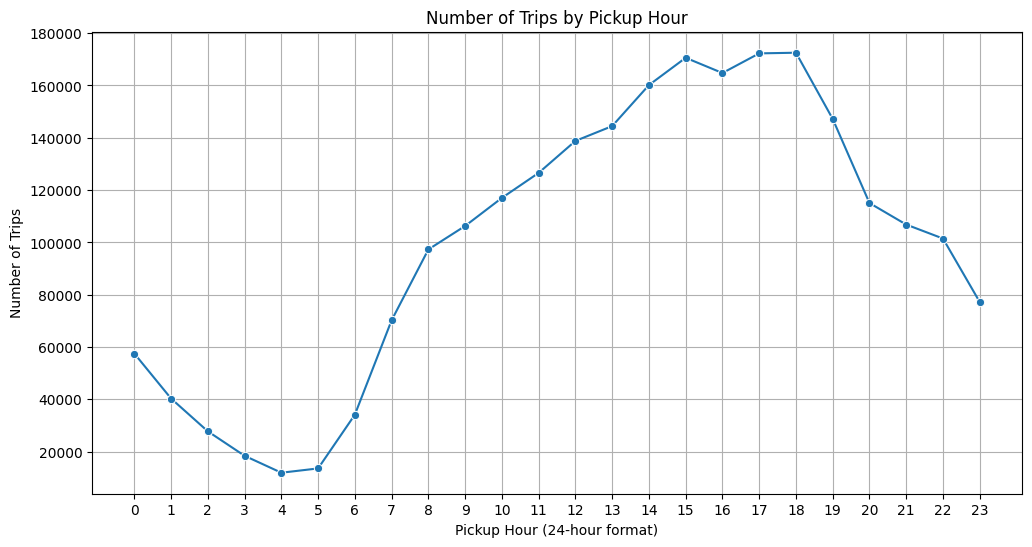

The busiest time of day is 18:00 with 172507 trips.


In [15]:
# Count the number of trips for each pickup hour
trips_per_hour = df_no_nulls['pickup_hour'].value_counts().sort_index()

# Create a DataFrame for plotting
trips_per_hour_df = trips_per_hour.reset_index()
trips_per_hour_df.columns = ['pickup_hour', 'number_of_trips']

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=trips_per_hour_df, x='pickup_hour', y='number_of_trips', marker='o')
plt.title('Number of Trips by Pickup Hour')
plt.xlabel('Pickup Hour (24-hour format)')
plt.ylabel('Number of Trips')
plt.xticks(range(24))  # Ensure all hours are displayed
plt.grid()
plt.show()

# Determine the busiest time of day
busiest_hour = trips_per_hour_df.loc[trips_per_hour_df['number_of_trips'].idxmax()]
print(f"The busiest time of day is {busiest_hour['pickup_hour']}:00 with {busiest_hour['number_of_trips']} trips.")


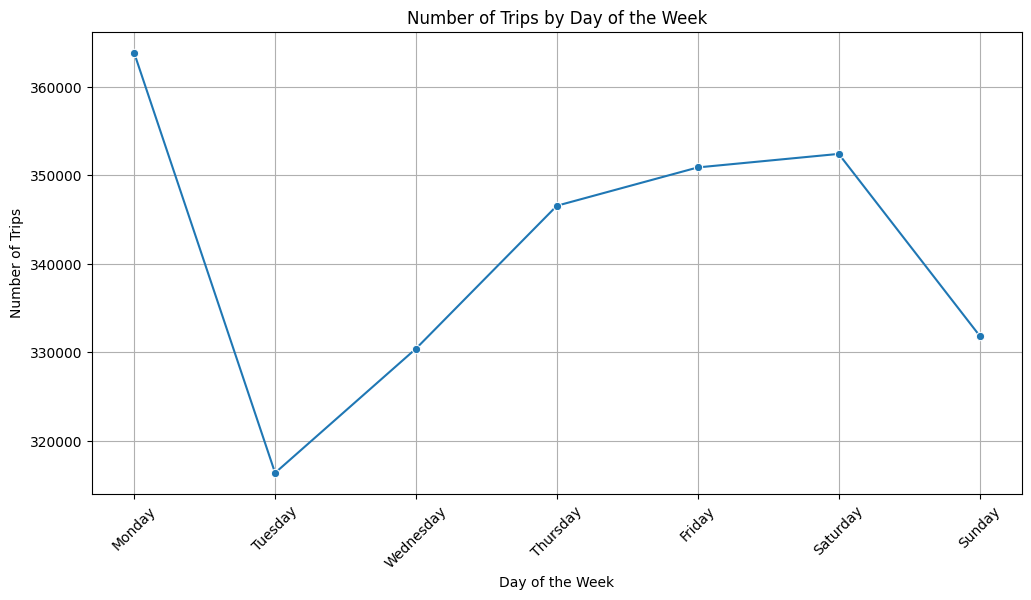

The least busy day of the week is Tuesday with 316408 trips.


In [16]:
# Count the number of trips for each day of the week
trips_per_day = df_no_nulls['pickup_day_of_week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Create a DataFrame for plotting
trips_per_day_df = trips_per_day.reset_index()
trips_per_day_df.columns = ['pickup_day_of_week', 'number_of_trips']

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=trips_per_day_df, x='pickup_day_of_week', y='number_of_trips', marker='o')
plt.title('Number of Trips by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.grid()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

# Determine the least busy day of the week
least_busy_day = trips_per_day_df.loc[trips_per_day_df['number_of_trips'].idxmin()]
print(f"The least busy day of the week is {least_busy_day['pickup_day_of_week']} with {least_busy_day['number_of_trips']} trips.")


In the realm of machine learning, understanding the relationships between variables is crucial for building accurate and effective predictive models. One powerful tool for exploring these relationships is the correlation matrix. A correlation matrix provides a comprehensive overview of the pairwise correlations between variables in a dataset, allowing practitioners to quantify and visualize the strength and direction of these associations. This matrix is an essential component of exploratory data analysis and offers several key benefits:

1. Relationship Assessment: The correlation matrix provides a quantitative measure of the relationship between variables. By calculating correlation coefficients, typically using methods like Pearson's correlation coefficient, analysts can determine if variables are positively correlated (increase together), negatively correlated (one increases as the other decreases), or uncorrelated (no systematic relationship). These measures offer insights into the direction and strength of the relationships, helping to identify important variables that may influence the target variable.

2. Feature Selection: Correlation matrices are invaluable in feature selection, which involves identifying the most relevant variables for building predictive models. By examining the correlations between the target variable and other features, analysts can identify highly correlated variables that may be strong predictors. This knowledge enables informed decisions regarding which variables to include in the model, potentially reducing dimensionality, enhancing model efficiency, and preventing issues such as multicollinearity.

3. Multicollinearity Detection: Multicollinearity occurs when two or more independent variables in a model are highly correlated. This can lead to problems such as instability in coefficient estimates, difficulty in interpreting feature importance, and reduced model robustness. By examining the correlation matrix, analysts can identify highly correlated variables and make informed decisions about which ones to include or exclude to mitigate multicollinearity. Removing redundant variables improves model interpretability and generalization.

Here is your task:

  1. Compute a correlation matrix between the variables 'trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'trip_duration' and use Seaborn to create a heatmap of the results. Which variables are strongly correlated?

Non-numeric columns: ['pickup_day_of_week']


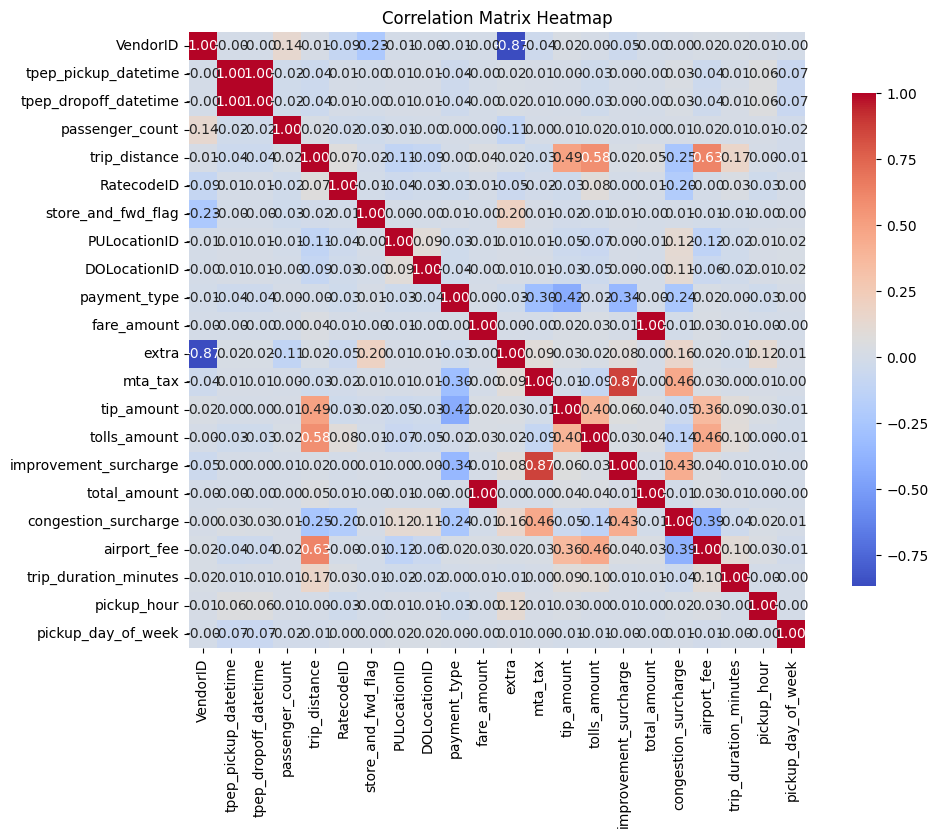

              Variable 1             Variable 2  Correlation Coefficient
0                  extra               VendorID                -0.866841
1  tpep_dropoff_datetime   tpep_pickup_datetime                 0.999993
2   tpep_pickup_datetime  tpep_dropoff_datetime                 0.999993
3           total_amount            fare_amount                 0.999878
4               VendorID                  extra                -0.866841
5  improvement_surcharge                mta_tax                 0.865924
6                mta_tax  improvement_surcharge                 0.865924
7            fare_amount           total_amount                 0.999878


In [22]:
import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Assuming df_no_nulls is already defined and cleaned

# Step 1: Identify non-numeric columns
non_numeric_columns = df_no_nulls.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric_columns)

# Step 2: Convert categorical columns to numeric
label_encoder = LabelEncoder()
for col in non_numeric_columns:
    # Convert all categorical columns to numeric
    df_no_nulls.loc[:, col] = label_encoder.fit_transform(df_no_nulls[col])

# Optional: Drop datetime columns if necessary
# df_no_nulls = df_no_nulls.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

# Step 3: Recompute the correlation matrix
correlation_matrix = df_no_nulls.corr()

# Step 4: Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.show()

# Step 5: Identify strongly correlated pairs
threshold = 0.7  # Define your threshold
strongly_correlated_pairs = []

# Loop through the correlation matrix to find strong correlations
for col in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if col != row:  # Exclude self-correlation
            if abs(correlation_matrix.loc[row, col]) > threshold:
                strongly_correlated_pairs.append((row, col, correlation_matrix.loc[row, col]))

# Convert the list of strongly correlated pairs to a DataFrame for better readability
strongly_correlated_df = pd.DataFrame(strongly_correlated_pairs, columns=['Variable 1', 'Variable 2', 'Correlation Coefficient'])

# Display the strongly correlated pairs
print(strongly_correlated_df)


Pairplots, also known as scatterplot matrices, allow for the visualization of pairwise relationships between multiple variables simultaneously. Each subplot in the pairplot represents the scatterplot of one variable against another. Pairplots offer several advantages in EDA:

  - Variable Relationships: Pairplots enable analysts to explore the relationships between variables, revealing patterns such as linear or nonlinear correlations, clusters, or other associations. These visual cues guide further analysis, feature selection, or modeling decisions.

  - Multivariate Analysis: Pairplots help identify multivariate dependencies and interactions, highlighting how different variables jointly influence one another. This is particularly valuable in identifying potential confounding factors or discovering hidden interactions that may not be apparent when considering variables in isolation.

  - Outlier Detection: Pairplots can reveal potential outliers by showing data points that deviate significantly from the general pattern observed between variables. Outliers can indicate data anomalies or influential observations that may impact model performance.

  - Feature Importance: Pairplots provide an intuitive representation of the relative importance of different features. Variables exhibiting strong correlations or clear patterns may be more relevant for predictive modeling or feature selection.

  - Data Quality: Pairplots can help identify data quality issues, such as data entry errors or measurement inconsistencies. Patterns that do not align with expectations or exhibit unusual trends may signal data problems that require further investigation or preprocessing.

Here is your task:

  1. Create a [pairplot matrix](https://seaborn.pydata.org/generated/seaborn.pairplot.html) using Seaborn to observation the relationship between the following variables: trip_distance, fare_amount, tip_amount, total_amount, trip_duration. Note, pairplots can be memory intensive. Try sampling the dataset using the [sample method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) in Pandas. Which variables appear to have a strong relationship? Which variables seem to have no relationship?

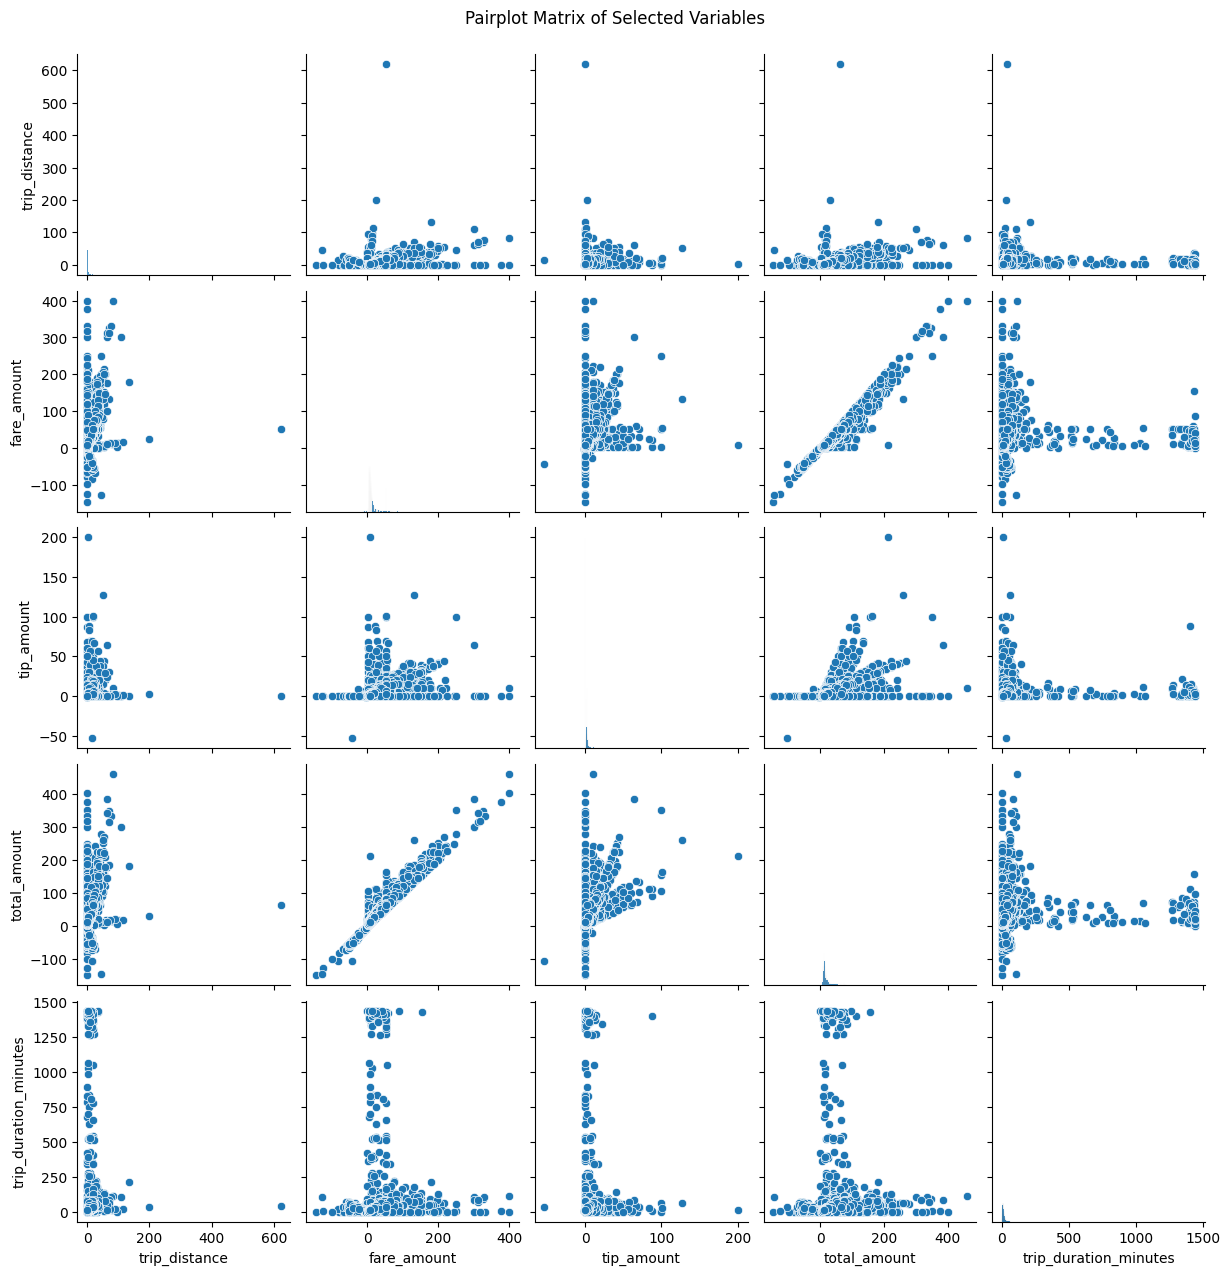

In [23]:
# Assuming df_no_nulls is already defined and cleaned

# Sample the dataset to reduce memory usage
sampled_df = df_no_nulls.sample(frac=0.1, random_state=1) # Adjust frac to control sample size

# Specify the variables of interest for the pairplot
variables_of_interest = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount', 'trip_duration_minutes']

# Create a pairplot matrix
pairplot = sns.pairplot(sampled_df[variables_of_interest])
plt.suptitle('Pairplot Matrix of Selected Variables', y=1.02) # Adjust title position
plt.show()

A count plot is a type of categorical plot that displays the number of occurrences of each category in a dataset. It is particularly useful for visualizing the distribution and frequency of categorical variables. Here are some key uses and benefits of count plots:

  - Categorical Variable Exploration: Count plots provide a quick and concise summary of the distribution of categorical variables. They allow analysts to understand the frequency or count of each category, revealing the proportions and imbalances within the dataset. This information is crucial for gaining insights into the composition and characteristics of categorical variables.

  - Class Imbalance Assessment: In classification tasks, count plots help assess the balance or imbalance of different target classes. It provides a visual representation of the distribution of classes, highlighting any significant discrepancies in the sample sizes across categories. Identifying imbalanced classes is important in machine learning as it can affect model performance and bias the predictions towards the majority class.

  - Data Quality Inspection: Count plots can be utilized to detect data quality issues in categorical variables. It allows analysts to identify unexpected or erroneous categories that may indicate data entry errors, missing data, or inconsistencies in the dataset. By observing the counts for each category, anomalies or discrepancies can be easily spotted, enabling data cleaning or further investigation if necessary.

  - Feature Importance Evaluation: Count plots can provide insights into the importance or relevance of different categorical features in relation to the target variable. By visualizing the distribution of categories within each class or target level, analysts can determine which categories are more prevalent or have higher frequencies for specific outcomes. This understanding helps in assessing the discriminatory power of categorical features and their potential impact on predictive models.

Here is your task:

  1. Use Seaborn to create a [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html) for the variables PULocationID, and DOLocationID. Keep only the top 15 pick-up and drop-off locations. What's the most popular pick-up location?

<ipython-input-24-be0176cdd39e>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='PULocationID', order=top_pu_locations, palette='viridis')
<ipython-input-24-be0176cdd39e>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_df, x='DOLocationID', order=top_do_locations, palette='viridis')


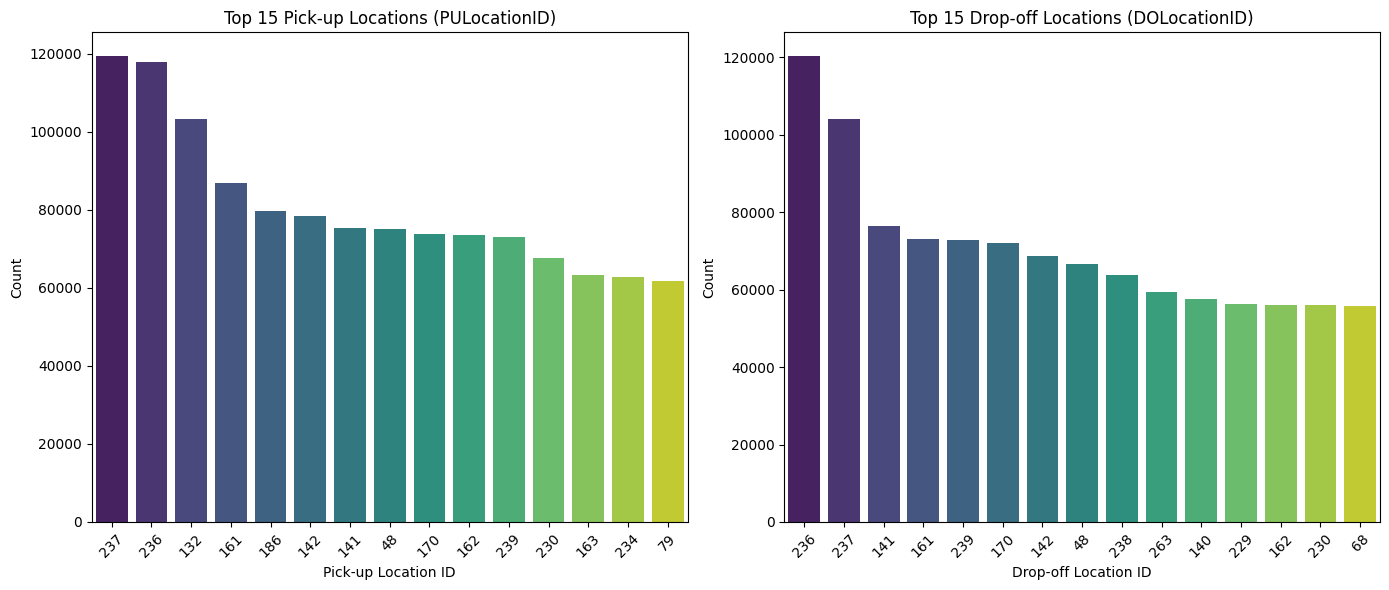

The most popular pick-up location (PULocationID) is: 237


In [24]:
# Assuming df_no_nulls is already defined and cleaned

# Step 1: Get the top 15 pick-up locations
top_pu_locations = df_no_nulls['PULocationID'].value_counts().nlargest(15).index

# Step 2: Get the top 15 drop-off locations
top_do_locations = df_no_nulls['DOLocationID'].value_counts().nlargest(15).index

# Step 3: Filter the DataFrame for only top locations
filtered_df = df_no_nulls[df_no_nulls['PULocationID'].isin(top_pu_locations) |
                           df_no_nulls['DOLocationID'].isin(top_do_locations)]

# Step 4: Create the countplots
plt.figure(figsize=(14, 6))

# Countplot for PULocationID
plt.subplot(1, 2, 1)
sns.countplot(data=filtered_df, x='PULocationID', order=top_pu_locations, palette='viridis')
plt.title('Top 15 Pick-up Locations (PULocationID)')
plt.xlabel('Pick-up Location ID')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Countplot for DOLocationID
plt.subplot(1, 2, 2)
sns.countplot(data=filtered_df, x='DOLocationID', order=top_do_locations, palette='viridis')
plt.title('Top 15 Drop-off Locations (DOLocationID)')
plt.xlabel('Drop-off Location ID')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Determine the most popular pick-up location
most_popular_pickup = df_no_nulls['PULocationID'].value_counts().idxmax()
print(f"The most popular pick-up location (PULocationID) is: {most_popular_pickup}")


A box plot, also known as a box-and-whisker plot, is a powerful visualization tool for displaying the distribution, variability, and outliers within a numerical dataset. It provides a concise summary of key statistical measures and offers several important uses:

  - Data Distribution and Skewness: Box plots offer a visual representation of the distribution of numerical data, providing insights into its central tendency, spread, and skewness. The box represents the interquartile range (IQR), which contains the middle 50% of the data, with the median indicated by a horizontal line within the box. By observing the length and symmetry of the box, analysts can assess whether the data is skewed or symmetrically distributed.

  - Outlier Detection: Box plots are highly effective in identifying outliers, which are data points that deviate significantly from the rest of the distribution. The whiskers of the plot extend to the minimum and maximum non-outlier values, with any data points beyond the whiskers considered as potential outliers. Outliers can indicate data errors, anomalies, or important observations requiring further investigation.

  - Comparing Groups or Categories: Box plots are useful for comparing the distributions of numerical data across different groups or categories. By creating side-by-side or grouped box plots, analysts can easily compare the central tendencies, spreads, and shapes of distributions between different groups. This allows for the identification of differences, similarities, or patterns within the data.

  - Variability and Spread: Box plots provide insights into the variability and spread of the data. The length of the box indicates the spread of the middle 50% of the data, while the whiskers show the range of non-outlier values. By comparing the lengths of the boxes and whiskers, analysts can assess the relative variability between different groups or categories, aiding in the understanding of the data's dispersion.

  - Skewedness and Symmetry: Box plots offer a visual assessment of the skewness or symmetry of the data distribution. A symmetrical distribution is represented by a box plot with an equal length on both sides of the median, while a skewed distribution is indicated by a longer box on one side. This visual cue helps in understanding the shape and characteristics of the data, assisting in further analysis and modeling decisions.

  - Data Range and Quartiles: Box plots display the quartiles of the data distribution. The lower quartile (Q1) represents the 25th percentile, the upper quartile (Q3) represents the 75th percentile, and the interquartile range (IQR) is the range between Q1 and Q3. These quartiles provide a summary of the range and spread of the central portion of the data, aiding in the understanding of the data's variability and dispersion.

Your task is:

  1. Use Seaborn's [boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html) to discern the relationship between payment_type and total_amount. Does anything look weird? Can you explain what's going on?

<ipython-input-25-ae53f08caede>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_no_nulls, x='payment_type', y='total_amount', palette='Set2')


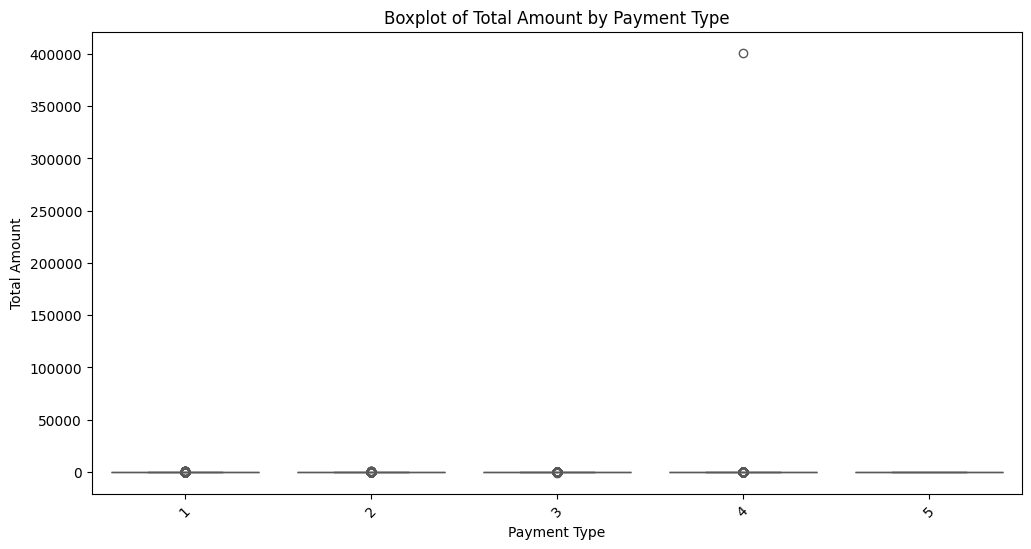

                  count       mean          std     min   25%   50%    75%  \
payment_type                                                                 
1             1874874.0  19.730785    15.152735 -108.81  11.8  14.8  20.16   
2              495171.0  16.363956    14.090348 -190.30   9.3  12.3  17.30   
3               11709.0   7.762433    20.044642 -480.30  -3.8   7.8  13.80   
4               10673.0  30.753316  3882.570743 -408.85 -13.3  -8.3   6.30   
5                   1.0  11.800000          NaN   11.80  11.8  11.8  11.80   

                    max  
payment_type             
1                899.68  
2                688.35  
3                376.30  
4             401095.62  
5                 11.80  
Number of outliers in total_amount: 259149


In [25]:
# Assuming df_no_nulls is already defined and cleaned

# Create a boxplot to analyze the relationship between payment_type and total_amount
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_no_nulls, x='payment_type', y='total_amount', palette='Set2')
plt.title('Boxplot of Total Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

# Analyze the data programmatically for outliers or unusual patterns
# Calculate summary statistics for total_amount by payment_type
summary_stats = df_no_nulls.groupby('payment_type')['total_amount'].describe()
print(summary_stats)

# Check for outliers using the interquartile range (IQR)
Q1 = df_no_nulls['total_amount'].quantile(0.25)
Q3 = df_no_nulls['total_amount'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df_no_nulls[(df_no_nulls['total_amount'] < lower_bound) | (df_no_nulls['total_amount'] > upper_bound)]
print(f"Number of outliers in total_amount: {len(outliers)}")

A histogram is a graphical representation that displays the distribution of a continuous or discrete numerical variable. It provides insights into the underlying data distribution and helps uncover patterns, frequencies, and ranges within the dataset. Here are some key uses and benefits of histogram plots:

  - Data Distribution: Histograms allow analysts to visualize the shape, central tendency, and spread of the data. They provide an overview of the data distribution, helping to identify if it follows a particular pattern, such as a normal distribution, skewed distribution, bimodal distribution, or multimodal distribution. Understanding the data distribution aids in selecting appropriate analysis techniques and understanding the characteristics of the data.

  - Frequency Analysis: Histograms display the frequency or count of data points within predefined bins or intervals along the x-axis. By observing the height or count of each bin, analysts can identify the frequency of occurrence for different values or value ranges. This information helps assess the concentration of data points and identify peaks or modes in the distribution.

  - Outlier Detection: Histograms can assist in identifying outliers, which are data points that significantly deviate from the rest of the distribution. Outliers may indicate data errors, unusual observations, or important anomalies requiring further investigation. By examining the tails or extreme values in the histogram, analysts can identify potential outliers that may require additional scrutiny.

  - Data Range and Spread: Histograms provide insights into the range and spread of the data. The x-axis represents the variable's values, while the y-axis represents the frequency or count of occurrences. By observing the width and span of the histogram, analysts can assess the data's range and variability. This information helps understand the data's spread and aids in subsequent analysis or decision-making processes.

  - Feature Engineering: Histograms can guide feature engineering processes by informing appropriate transformations, binning strategies, or encoding techniques for numerical variables. They assist in identifying nonlinear relationships or determining optimal cut-off points for converting continuous variables into categorical ones. Histograms also help identify data skewness and guide transformation methods to address the skew if necessary.

  - Data Quality Inspection: Histograms can be useful in detecting data quality issues or anomalies. Unusual spikes, gaps, or unexpected patterns in the histogram may indicate data entry errors, measurement inconsistencies, or missing data. By observing the histogram, analysts can identify potential data quality issues that require further investigation or preprocessing.

Your task is:

  1. Use Seaborn's [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) to explore the data distributions for fare_amount, trip_distance, and extra. Use kernel density estimators to better visualize the distribution. Use sampling if you run into any memory issues.

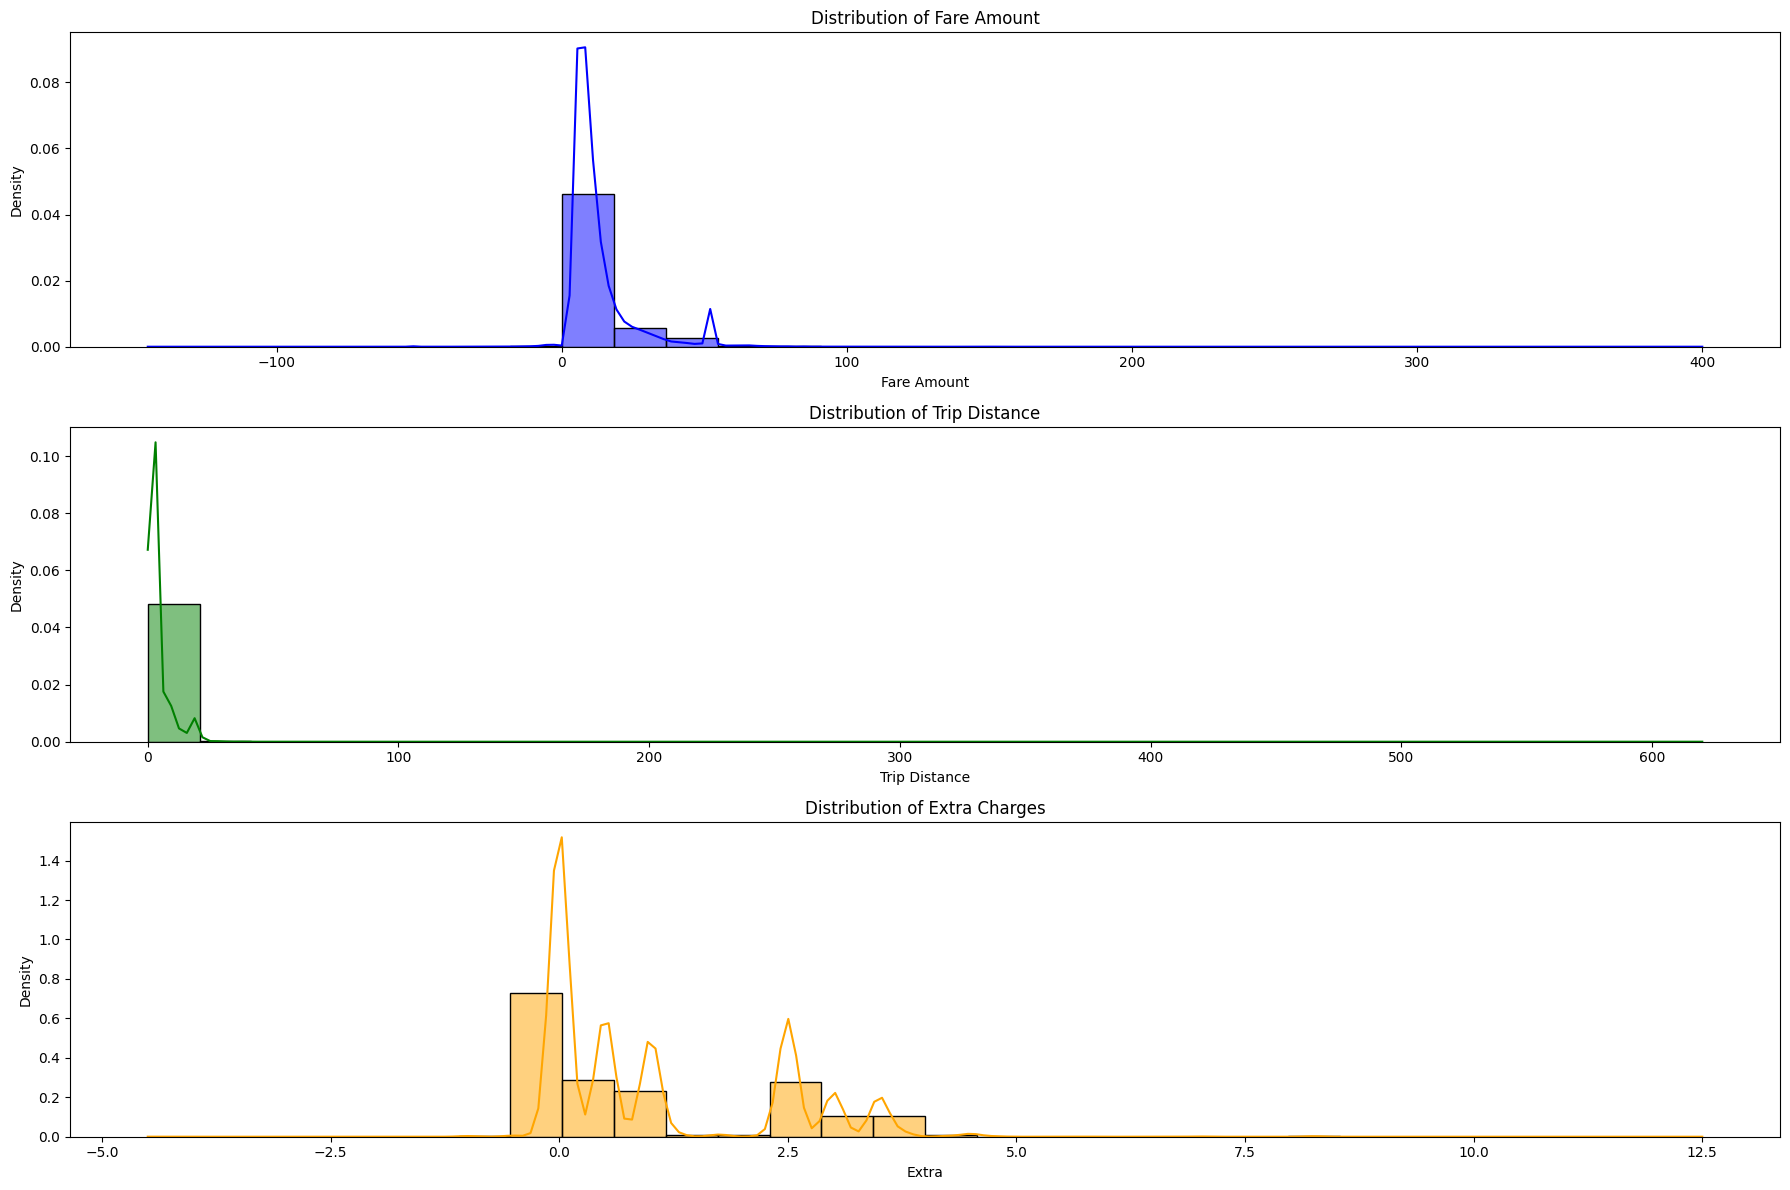

In [26]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# Assuming df_no_nulls is already defined and cleaned

# Sample the data if memory issues arise (10% sample here, adjust as necessary)
sampled_df = df_no_nulls.sample(frac=0.1, random_state=1)

# Set up the figure for the histplots
plt.figure(figsize=(18, 12))

# Plot for fare_amount
plt.subplot(3, 1, 1)
sns.histplot(sampled_df['fare_amount'], bins=30, kde=True, color='blue', stat='density')
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Density')

# Plot for trip_distance
plt.subplot(3, 1, 2)
sns.histplot(sampled_df['trip_distance'], bins=30, kde=True, color='green', stat='density')
plt.title('Distribution of Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Density')

# Plot for extra
plt.subplot(3, 1, 3)
sns.histplot(sampled_df['extra'], bins=30, kde=True, color='orange', stat='density')
plt.title('Distribution of Extra Charges')
plt.xlabel('Extra')
plt.ylabel('Density')

# Adjust layout for better readability
plt.tight_layout()
plt.show()
